# RNN Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- Standardized features
- RNN (GRU-based) with PyTorch
- Handles class imbalance with weighted loss

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4090 Laptop GPU



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\kangy\miniconda3\envs\dsc180-prism\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\kangy\miniconda3\envs\dsc180-prism\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\kangy\miniconda3\envs\dsc180-prism\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

## 1. Load Data & Selected Features

In [2]:
# Load features
features_df = pd.read_csv('features.csv', index_col=0)

# Load selected feature names
with open('selected_features_top50.txt', 'r') as f:
    selected_features = [line.strip() for line in f if line.strip()]

print(f'Total consumers: {features_df.shape[0]}')
print(f'Selected features: {len(selected_features)}')
print(f'Delinquency rate: {features_df["DQ_TARGET"].mean():.2%}')

Total consumers: 12900
Selected features: 50
Delinquency rate: 8.86%


## 2. Prepare Data & Train/Val/Test Split

In [3]:
# Clean and subset
df_clean = features_df[features_df['DQ_TARGET'].notna()].copy()
y = df_clean['DQ_TARGET'].astype(int).values

# Keep only selected features
available_features = [f for f in selected_features if f in df_clean.columns]
X = df_clean[available_features].fillna(0).values

print(f'Features used: {len(available_features)}')
print(f'Samples: {X.shape[0]}')
print(f'Class distribution: 0={np.sum(y==0)}, 1={np.sum(y==1)}')

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: 50/50 of temp -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'\nTrain: {X_train.shape[0]} ({y_train.mean():.2%} positive)')
print(f'Val:   {X_val.shape[0]} ({y_val.mean():.2%} positive)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.2%} positive)')

Features used: 50
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


In [4]:
# Standardize features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape for RNN: (batch, seq_len, input_size)
# Treat each feature as a time step with 1 input dimension
n_features = X_train_scaled.shape[1]
X_train_rnn = X_train_scaled.reshape(-1, n_features, 1)
X_val_rnn = X_val_scaled.reshape(-1, n_features, 1)
X_test_rnn = X_test_scaled.reshape(-1, n_features, 1)

print(f'RNN input shape: {X_train_rnn.shape}  (batch, seq_len={n_features}, input_size=1)')

# Create DataLoaders
def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_rnn, y_train, shuffle=True)
val_loader = make_loader(X_val_rnn, y_val, shuffle=False)
test_loader = make_loader(X_test_rnn, y_test, shuffle=False)

print(f'Batches -> Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

RNN input shape: (6190, 50, 1)  (batch, seq_len=50, input_size=1)
Batches -> Train: 25, Val: 9, Test: 9


## 3. Define RNN Model

In [5]:
class DelinquencyRNN(nn.Module):
    """GRU-based RNN for binary classification."""
    
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 1),
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        gru_out, _ = self.gru(x)  # (batch, seq_len, hidden*2)
        
        # Attention pooling
        attn_weights = self.attention(gru_out)  # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * gru_out, dim=1)  # (batch, hidden*2)
        
        out = self.classifier(context)  # (batch, 1)
        return out.squeeze(-1)

model = DelinquencyRNN(input_size=1, hidden_size=64, num_layers=2, dropout=0.3).to(device)
print(model)
print(f'\nParameters: {sum(p.numel() for p in model.parameters()):,}')

DelinquencyRNN(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=1, bias=True)
    (1): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parameters: 104,514


## 4. Training

In [7]:
# Class weight for imbalanced data
pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)]).to(device)
print(f'Positive class weight: {pos_weight.item():.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

# Training loop
NUM_EPOCHS = 50
PATIENCE = 10

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_val_auc = 0
patience_counter = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # --- Validate ---
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_losses.append(criterion(logits, y_batch).item())
            val_preds.extend(torch.sigmoid(logits).cpu().tolist())
            val_targets.extend(y_batch.cpu().tolist())
    
    avg_val_loss = np.mean(val_losses)
    val_auc = roc_auc_score(val_targets, val_preds)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_auc'].append(val_auc)
    
    scheduler.step(avg_val_loss)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f} '
              f'{"*" if patience_counter == 0 else ""}')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}. Best Val AUC: {best_val_auc:.4f}')
        break

# Restore best model
if best_state:
    model.load_state_dict(best_state)
    model.to(device)
print(f'\nBest Validation AUC: {best_val_auc:.4f}')

Positive class weight: 10.30
Epoch   1 | Train Loss: 1.2527 | Val Loss: 1.1961 | Val AUC: 0.5667 *
Epoch   2 | Train Loss: 1.2402 | Val Loss: 1.1961 | Val AUC: 0.5672 *
Epoch   3 | Train Loss: 1.2325 | Val Loss: 1.1892 | Val AUC: 0.5709 *
Epoch   4 | Train Loss: 1.2460 | Val Loss: 1.1858 | Val AUC: 0.5750 *
Epoch   5 | Train Loss: 1.2420 | Val Loss: 1.1826 | Val AUC: 0.6090 *
Epoch   6 | Train Loss: 1.2295 | Val Loss: 1.1749 | Val AUC: 0.6241 *
Epoch  10 | Train Loss: 1.2156 | Val Loss: 1.1597 | Val AUC: 0.6185 
Epoch  15 | Train Loss: 1.2064 | Val Loss: 1.1604 | Val AUC: 0.6211 
Epoch  16 | Train Loss: 1.1922 | Val Loss: 1.1620 | Val AUC: 0.6286 *
Epoch  18 | Train Loss: 1.2060 | Val Loss: 1.1375 | Val AUC: 0.6385 *
Epoch  19 | Train Loss: 1.1603 | Val Loss: 1.1213 | Val AUC: 0.6540 *
Epoch  20 | Train Loss: 1.1601 | Val Loss: 1.1016 | Val AUC: 0.6677 *
Epoch  21 | Train Loss: 1.1161 | Val Loss: 1.1090 | Val AUC: 0.6825 *
Epoch  22 | Train Loss: 1.1064 | Val Loss: 1.0949 | Val AUC: 0.

## 5. Training Curves

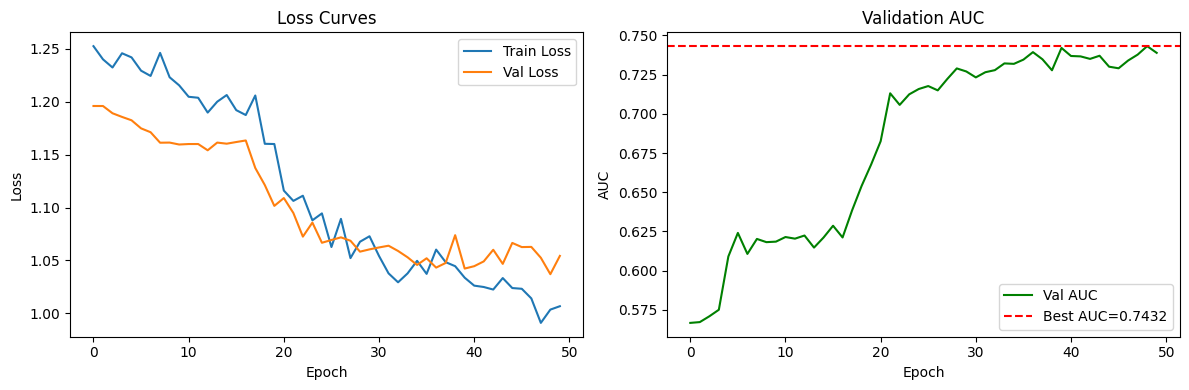

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(history['val_auc'], label='Val AUC', color='green')
axes[1].axhline(y=best_val_auc, color='r', linestyle='--', label=f'Best AUC={best_val_auc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Validation AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluation on All Splits

In [9]:
def evaluate(model, loader, split_name):
    """Evaluate model and print metrics."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().tolist()
            all_preds.extend(probs)
            all_targets.extend(y_batch.tolist())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # AUC
    auc = roc_auc_score(all_targets, all_preds)
    ap = average_precision_score(all_targets, all_preds)
    
    # Binary predictions at 0.5 threshold
    y_pred = (all_preds >= 0.5).astype(int)
    
    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(all_targets, y_pred, target_names=['No DQ', 'DQ']))
    print(f'Confusion Matrix:')
    print(confusion_matrix(all_targets, y_pred))
    
    return all_preds, all_targets, auc

train_preds, train_targets, train_auc = evaluate(model, train_loader, 'TRAIN')
val_preds, val_targets, val_auc = evaluate(model, val_loader, 'VALIDATION')
test_preds, test_targets, test_auc = evaluate(model, test_loader, 'TEST')


TRAIN Results
ROC-AUC: 0.8019
Average Precision: 0.2784

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.97      0.66      0.79      5642
          DQ       0.18      0.79      0.30       548

    accuracy                           0.67      6190
   macro avg       0.58      0.73      0.54      6190
weighted avg       0.90      0.67      0.74      6190

Confusion Matrix:
[[3721 1921]
 [ 114  434]]

VALIDATION Results
ROC-AUC: 0.7432
Average Precision: 0.2055

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.96      0.65      0.77      1880
          DQ       0.16      0.69      0.26       183

    accuracy                           0.65      2063
   macro avg       0.56      0.67      0.52      2063
weighted avg       0.89      0.65      0.73      2063

Confusion Matrix:
[[1215  665]
 [  56  127]]

TEST Results
ROC-AUC: 0.7324
Average Precision: 0.2282

Classification Report:
         

## 7. Precision-Recall Curves

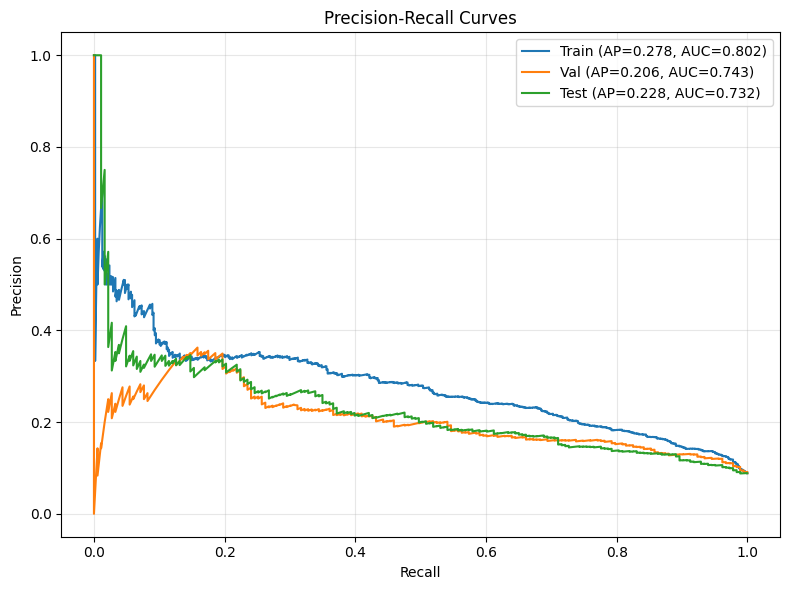

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_val in [
    (train_preds, train_targets, 'Train', train_auc),
    (val_preds, val_targets, 'Val', val_auc),
    (test_preds, test_targets, 'Test', test_auc)
]:
    precision, recall, _ = precision_recall_curve(targets, preds)
    ap = average_precision_score(targets, preds)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f}, AUC={auc_val:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

In [11]:
print('RNN Model Summary')
print('=' * 40)
print(f'Architecture: Bidirectional GRU')
print(f'Hidden size: 64, Layers: 2')
print(f'Features used: {len(available_features)}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'')
print(f'          AUC')
print(f'Train:    {train_auc:.4f}')
print(f'Val:      {val_auc:.4f}')
print(f'Test:     {test_auc:.4f}')

RNN Model Summary
Architecture: Bidirectional GRU
Hidden size: 64, Layers: 2
Features used: 50
Parameters: 104,514

          AUC
Train:    0.8019
Val:      0.7432
Test:     0.7324
